# 📘Домашнє завдання №15 Основи часових рядів: компоненти, типи, проблеми

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW15

### Завдання 1. Побудова графіка

Побудуйте графік часового ряду.

**Потрібно визначити:**

* чи є тренд;
* чи є сезонність;
* чи помітні аномалії.

---

### Завдання 2. Пошук проблем у даних

Знайдіть у часовому ряді:

* пропущені значення
* аутлаєри
* можливий шум

---

### Завдання 3. Обробка пропусків

Заповніть пропущені значення одним із методів:

* інтерполяція
* середнє значення
* попереднє значення

Побудуйте графік після виправлення.

---

### Завдання 4. Обробка аутлаєрів

Знайдіть аномальні значення та:

* видаліть їх
  або
* замініть коректними значеннями

Побудуйте оновлений графік.

---

### Завдання 5. Виділення компонентів часового ряду

Використайте `seasonal_decompose()` та виділіть:

* trend
* seasonal
* residual

---

### Завдання 6. Ковзне середнє

Побудуйте:

* 7-денне ковзне середнє
* 30-денне ковзне середнє

Порівняйте результати, побудувавши відповідні графіки.

---

### Завдання 7. Експоненційне згладжування

Застосуйте експоненційне згладжування, побудувавши відповідні графіки.

Спробуйте різні значення параметра `alpha`:

* 0.2
* 0.5
* 0.8

Порівняйте результати.

In [1]:
# TODO: uncommit
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "kagglehub[pandas-datasets]",
#     "numpy",
#     "pandas",
#     "matplotlib",
#     "scipy",
#     "scipy-stubs",
#     "statsmodels",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# TODO: uncommit
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input data
# hm_version = 15
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone data
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

## ✅ Рішення 1

Побудуйте графік часового ряду.

**Потрібно визначити:**

* чи є тренд;
* чи є сезонність;
* чи помітні аномалії.

In [3]:
# Data synthesis

import numpy as np
import pandas as pd
from IPython.display import display

# Input data
rng_seed = 42
use_sign = False

# Solution
np.random.seed(rng_seed)

# створюємо часову шкалу
dates = pd.date_range(start='2024-01-01', periods=365, freq='D')
# тренд
trend = np.linspace(100, 200, len(dates))
# сезонність
seasonality = 30 * np.sin(2 * np.pi * np.arange(len(dates)) / 30)
# шум
noise = np.random.normal(0, 10, len(dates))
# базовий ряд
sales = trend + seasonality + noise

# додаємо пропуски
missing_idx = np.asarray(np.random.choice(len(dates), size=15, replace=False))
sales[missing_idx] = np.nan

# додаємо аутлаєри
outlier_idx = np.asarray(np.random.choice(len(dates), size=10, replace=False))
sales[outlier_idx] *= 2.5

if use_sign:
    sales[outlier_idx] *= np.random.choice([1, -1], size=outlier_idx.size)

# створюємо DataFrame
df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

# Print results
display(df)


,date,sales
0,2024-01-01,104.967142
1,2024-01-02,105.129433
2,2024-01-03,119.228435
3,2024-01-04,133.688032
4,2024-01-05,121.051712
...,...,...
360,2024-12-26,204.094564
361,2024-12-27,220.740564
362,2024-12-28,NaN
363,2024-12-29,221.375950


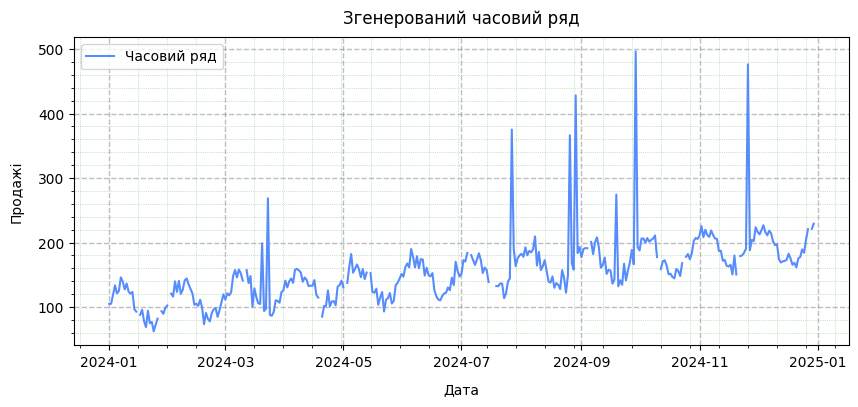

In [4]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["date"], df["sales"], label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Згенерований часовий ряд", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Продажі", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

In [20]:
# Аналіз наявності сезонності

import numpy as np
from scipy import signal

# Input data
window_size = 14
trim_size = window_size // 2

# Solution
temp_df = df.copy()
temp_df.dropna(inplace=True)
temp_df["id"] = temp_df.index

g_fun = np.ones(window_size) / window_size
f_fun = temp_df["sales"].values
smoothed_data = signal.fftconvolve(f_fun, g_fun, mode='same')

# 2-ге згладжування для похідної
smoothed_data2 = signal.fftconvolve(smoothed_data, g_fun, mode='same')

# беремо похідну (градієнт зберігає кількість точок)
# derivative = np.diff(smoothed_data2)
derivative = np.gradient(smoothed_data2)
derivative = signal.fftconvolve(derivative, g_fun, mode='same')
temp_df["derivative"] = derivative

# Порівнюємо значення зі зміщенням масиву
peaks = (derivative > 0) & (np.roll(derivative, -1) <= 0)
temp_df["peak"] = peaks

# знаходимо індекси
indices = temp_df.loc[peaks, "id"]
period = np.diff(indices)
period_mean = np.mean(period)
period_cycle = np.ceil(period_mean).astype(int)

temp_df["smoothed"] = smoothed_data
temp_df["smoothed2"] = smoothed_data2

# видаляємо некоректні значення по краях, щоб зменшити вплив значень на тренд
temp_df = temp_df.iloc[trim_size:-trim_size]

# Print results
# display(temp_df)


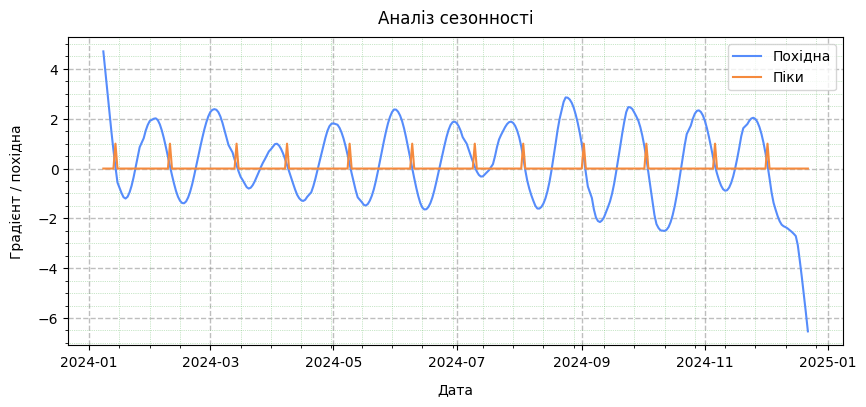

In [6]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(temp_df["date"], temp_df["derivative"], label="Похідна")
ax.plot(temp_df["date"], temp_df["peak"], label="Піки")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Аналіз сезонності", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Градієнт / похідна", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

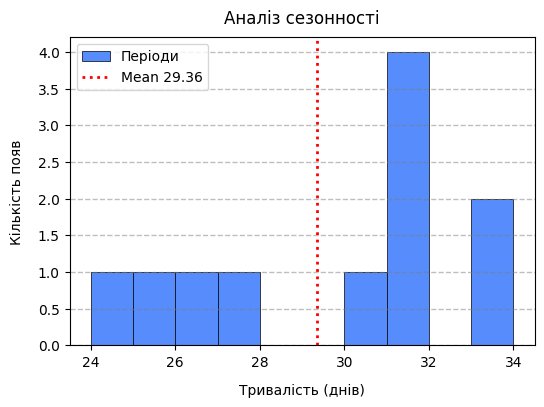

In [7]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(6, 4))

ax.hist(period, edgecolor="black", linewidth=0.5, label="Періоди")
ax.axvline(float(period_mean), linestyle=':', color='red', linewidth=2.0, label=f"Mean {period_mean:.2f}")

ax.grid(axis='y', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Аналіз сезонності", pad=10, loc='center', color='black')
ax.set_xlabel("Тривалість (днів)", labelpad=10, loc='center', color='black')
ax.set_ylabel("Кількість появ", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

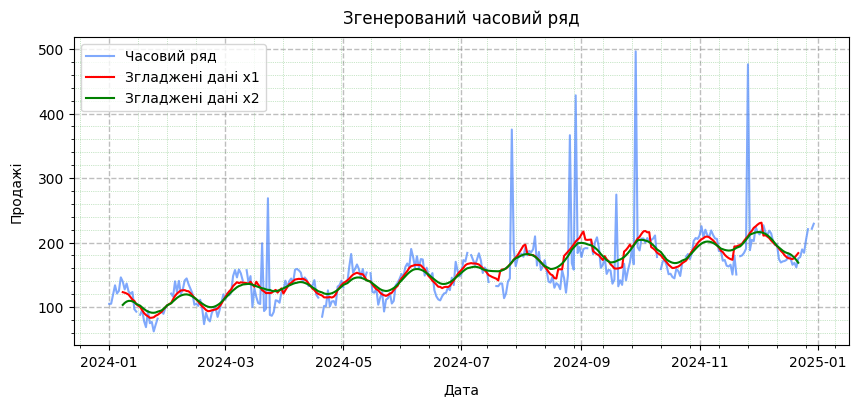

In [8]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["date"], df["sales"], alpha=0.75, label="Часовий ряд")
ax.plot(temp_df["date"], temp_df["smoothed"], color='red', label="Згладжені дані x1")
ax.plot(temp_df["date"], temp_df["smoothed2"], color='green', label="Згладжені дані x2")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Згенерований часовий ряд", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Продажі", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

In [9]:
# Аналіз наявності аномалій/викидів

import apps.reporter as rpt

# Input data

# Solution
temp_df["st_sales"] = temp_df.apply(lambda row: row["sales"] - row["smoothed"], axis=1)

# Розрахунок викидів
col_data = temp_df[["id", "st_sales"]]
Q1 = col_data["st_sales"].quantile(0.25)
Q3 = col_data["st_sales"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = [int(idx) for (idx, value) in col_data.values if value < lower_limit or value > upper_limit]
n_outliers = len(outliers)

# зберігаємо мітку аутлаєра
# df['outlier'] = df.index.isin(outliers)
df['outlier'] = df.apply(lambda row: row.name in outliers, axis=1)

rp = rpt.Reporter()
rp.tolerance = 6
rp.add_item("Наявність аномалій", 'є' if n_outliers > 0 else 'немає')
rp.add_item("Кількість знайдених викидів", str(n_outliers))

# Print results
rp.print_pd_report("Кількість викидів/outliers")

Attribute,Result
Наявність аномалій,є
Кількість знайдених викидів,12


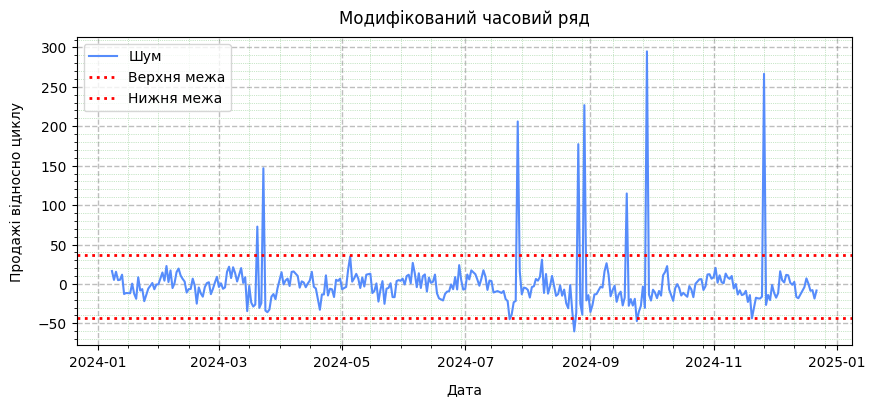

In [10]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(temp_df["date"], temp_df["st_sales"], label="Шум")

ax.axhline(upper_limit, linestyle=':', color='red', linewidth=2.0, label="Верхня межа")
ax.axhline(lower_limit, linestyle=':', color='red', linewidth=2.0, label="Нижня межа")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Модифікований часовий ряд", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Продажі відносно циклу", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

In [11]:
# Аналіз наявності тренду

import apps.reporter as rpt
from sklearn.linear_model import LinearRegression

# Input data

# Solution
X_data = temp_df["id"].values.reshape(-1, 1)
Y_data = temp_df["smoothed"].values.reshape(-1, 1)

model_line = LinearRegression()
model_line.fit(X_data, Y_data)
beta0 = model_line.intercept_
beta1 = model_line.coef_[0]
beta1_deg = np.rad2deg(np.arctan(beta1))

Y_pred = model_line.predict(X_data)
temp_df["predicted"] = Y_pred

rp = rpt.Reporter()
rp.tolerance = 6
rp.add_item("Коефіцієнт β₀", rp.format_value(beta0.item(0)))
rp.add_item("Коефіцієнт β₁", rp.format_value(beta1.item(0)))
rp.add_item("Кут нахилу β₁", f"{beta1_deg.item(0):.2f}°")
rp.add_item("Наявність тренду", 'є' if beta0 > 0 else 'немає')

temp_df = df.copy()
temp_df["id"] = temp_df.index

X_data = temp_df["id"].values.reshape(-1, 1)
Y_pred = model_line.predict(X_data)
temp_df["predicted"] = Y_pred

# Print results
rp.print_pd_report("Параметри лінійної регресії")

Attribute,Result
Коефіцієнт β₀,99.668113
Коефіцієнт β₁,0.302835
Кут нахилу β₁,16.85°
Наявність тренду,є


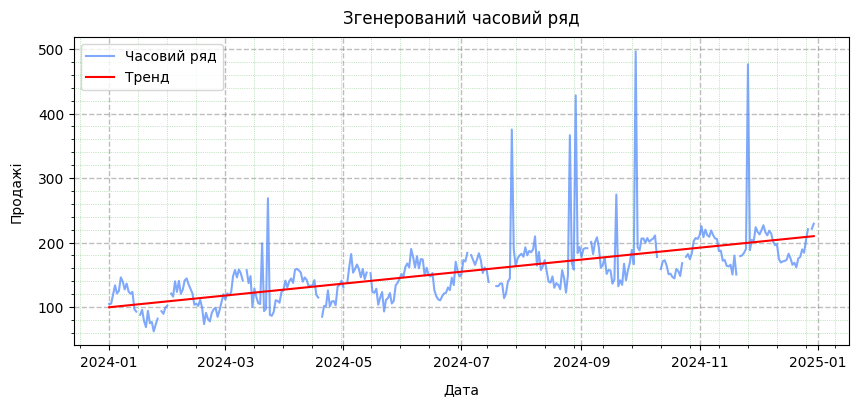

In [12]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["date"], df["sales"], alpha=0.75, label="Часовий ряд")
ax.plot(temp_df["date"], temp_df["predicted"], color='red', label="Тренд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Згенерований часовий ряд", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Продажі", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

Висновок. У приведеному часовому ряду присутній тренд та аномалії у вигляді викидів. Сезонність є і вона має середній період у 29 днів (діапазон 24–34 дні). Незначне відхилення тривалості періодів від середнього підтверджує наявність циклічності, яке залишається помітним навіть за наявності шуму та викидів.

## ✅ Рішення 2

Знайдіть у часовому ряді:

* пропущені значення
* аутлаєри
* можливий шум

In [13]:
# Data analysis

import pandas as pd
import apps.reporter as rpt

# Input data
data_set = df
n_columns = data_set.columns.size
n_rows = data_set.index.size

# Solution
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

empties_df = data_set[data_set.isna().any(axis=1)].drop("outlier", axis=1)

outliers_df = data_set[data_set["outlier"]].drop("outlier", axis=1)

rp = rpt.Reporter()
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')
rp.add_item("Пропущених значень", str(empty_val_by_col.sum().sum()))
rp.add_item("Наявність викидів", 'є' if n_outliers > 0 else 'немає')
rp.add_item("Кількість знайдених викидів", str(n_outliers))
rp.add_item("Наявність шуму", 'є' if (abs(upper_limit - lower_limit)) > 0 else 'немає')

# Print results
display(types_df.style.set_caption("Типи даних"))
rp.print_pd_report("Параметри таблиці до обробки")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
    display(empties_df.style.set_caption("Пропуски").
            format({"date": lambda t: t.strftime("%Y-%m-%d")}))

if n_outliers > 0:
    display(outliers_df.style.set_caption("Викиди").
            format({"date": lambda t: t.strftime("%Y-%m-%d")}))

# display(data_set)

,Types
date,datetime64[us]
sales,float64
outlier,bool


Attribute,Result
Кількість об’єктів у датасеті,365
Кількість стовпців,3
Пропущені значення,є
Пропущених значень,15
Наявність викидів,є
Кількість знайдених викидів,12
Наявність шуму,є


,count
date,0
sales,15
outlier,0


,date,sales
15,2024-01-16,nan
26,2024-01-27,nan
31,2024-02-01,nan
70,2024-03-11,nan
109,2024-04-19,nan
122,2024-05-02,nan
134,2024-05-14,nan
186,2024-07-05,nan
197,2024-07-16,nan
199,2024-07-18,nan


,date,sales
79,2024-03-20,198.833157
82,2024-03-23,268.676890
204,2024-07-23,113.735567
208,2024-07-27,375.228087
236,2024-08-24,122.289394
238,2024-08-26,366.411629
241,2024-08-29,428.246944
262,2024-09-19,274.324229
267,2024-09-24,141.416677
272,2024-09-29,496.397529


Примітка. Шум можна побачити на графіку "Модифікований часовий ряд". Даний графік був позбавлений тренду та сезонності, а отже, якби не було шуму, то лінія проходила вздовж осі Oy.

## ✅ Рішення 3

Заповніть пропущені значення одним із методів:

* інтерполяція
* середнє значення
* попереднє значення

Побудуйте графік після виправлення.

In [14]:
# Filling in the missing

# Input data

# Solution
df["sales_fixed"] = (df["sales"]
                     .interpolate(method="linear", limit_area="inside")  # заповнення в середині
                     .bfill()  # заповнення на початку першим значенням
                     .ffill())  # заповнення на кінці останнім значенням

data_set = df

empties_df = data_set[data_set.isna().any(axis=1)].drop("outlier", axis=1)

# Print results
display(empties_df.style.set_caption("Заповнення пропусків").
        format({"date": lambda t: t.strftime("%Y-%m-%d")}))

,date,sales,sales_fixed
15,2024-01-16,nan,90.432134
26,2024-01-27,nan,87.768800
31,2024-02-01,nan,111.541514
70,2024-03-11,nan,149.108373
109,2024-04-19,nan,99.831791
122,2024-05-02,nan,133.895745
134,2024-05-14,nan,153.031871
186,2024-07-05,nan,182.212968
197,2024-07-16,nan,138.057181
199,2024-07-18,nan,134.943150


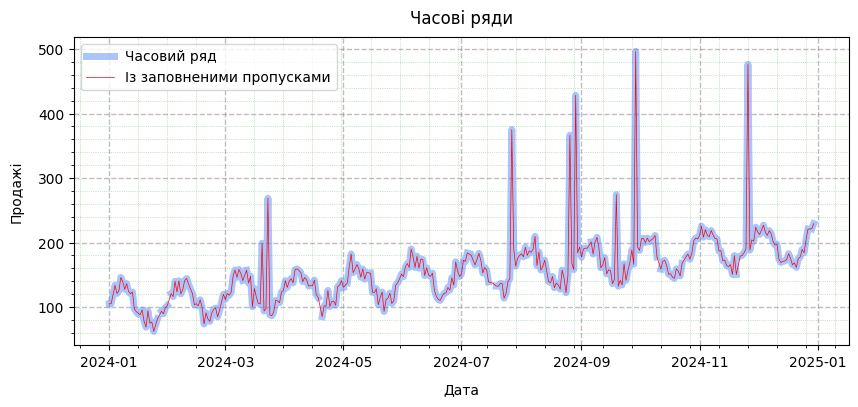

In [15]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["date"], df["sales"], linewidth=5.0, alpha=0.5, label="Часовий ряд")
ax.plot(df["date"], df["sales_fixed"], linewidth=0.5, color="red", label="Із заповненими пропусками")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Часові ряди", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Продажі", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

## ✅ Рішення 4

Знайдіть аномальні значення та:

* видаліть їх
  або
* замініть коректними значеннями

Побудуйте оновлений графік.

In [16]:
# Anomaly processing

import numpy as np

# Input data

# Solution
df.loc[df["outlier"], "sales_fixed"] = np.nan

df["sales_fixed"] = (df["sales_fixed"]
                     .interpolate(method="linear", limit_area="inside")  # заповнення в середині
                     .bfill()  # заповнення на початку першим значенням
                     .ffill())  # заповнення на кінці останнім значенням

outliers_df = data_set[data_set["outlier"]].drop("outlier", axis=1)

# Print results
display(outliers_df.style.set_caption("Викиди").
        format({"date": lambda t: t.strftime("%Y-%m-%d")}))

,date,sales,sales_fixed
79,2024-03-20,198.833157,99.256581
82,2024-03-23,268.676890,92.538008
204,2024-07-23,113.735567,128.715632
208,2024-07-27,375.228087,167.039990
236,2024-08-24,122.289394,147.129872
238,2024-08-26,366.411629,158.643599
241,2024-08-29,428.246944,170.872174
262,2024-09-19,274.324229,137.374781
267,2024-09-24,141.416677,162.065260
272,2024-09-29,496.397529,179.532583


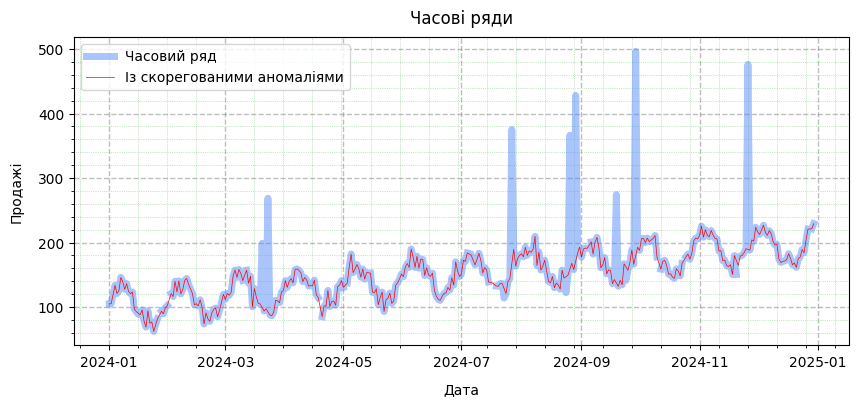

In [17]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["date"], df["sales"], linewidth=5.0, alpha=0.5, label="Часовий ряд")
ax.plot(df["date"], df["sales_fixed"], linewidth=0.5, color="red", label="Із скорегованими аномаліями")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Часові ряди", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Продажі", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

## ✅ Рішення 5

Використайте `seasonal_decompose()` та виділіть:

* trend
* seasonal
* residual

In [50]:
# Data decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

# Input data

# Solution
df_decompose = df.set_index("date")
decomposed_data = seasonal_decompose(df_decompose["sales_fixed"], model='additive', period=period_cycle)

# Print results

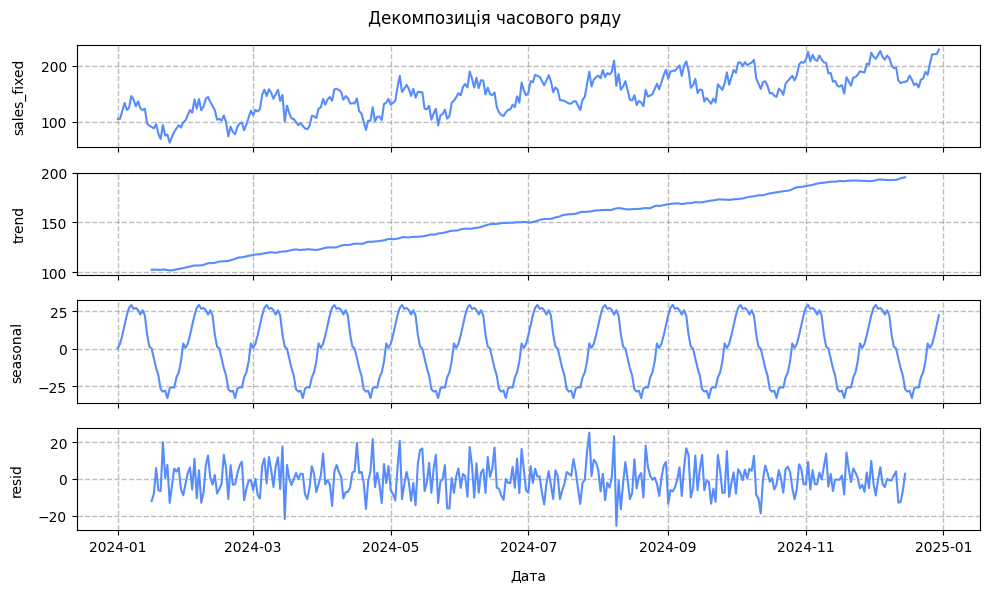

In [51]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
decomposed_array = [
    decomposed_data.observed,
    decomposed_data.trend,
    decomposed_data.seasonal,
    decomposed_data.resid,
]

# Solution
_, axes = plt.subplots(len(decomposed_array), 1, figsize=(10, 6), sharex=True)

for idx, item in enumerate(decomposed_array):
    ax = axes[idx]
    ax.plot(item)
    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    # ax.minorticks_on()
    # ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_ylabel(f"{item.name}", labelpad=10, loc='center', color='black')

axes[-1].set_xlabel("Дата", labelpad=10, loc='center', color='black')

plt.suptitle(f"Декомпозиція часового ряду")

plt.tight_layout()
plt.show()

## ✅ Рішення 6

Побудуйте:

* 7-денне ковзне середнє
* 30-денне ковзне середнє

Порівняйте результати, побудувавши відповідні графіки.

In [58]:
# Ковзне середнє

# Input data
windows_sizes = [7, 30]

# Solution
for size in windows_sizes:
    col_name = f"moving_avg_{size}"
    df[col_name] = df["sales_fixed"].rolling(window=size).mean()

# Print results
display(df)

,date,sales,outlier,sales_fixed,moving_avg_7,moving_avg_30
0,2024-01-01,104.967142,False,104.967142,NaN,NaN
1,2024-01-02,105.129433,False,105.129433,NaN,NaN
2,2024-01-03,119.228435,False,119.228435,NaN,NaN
3,2024-01-04,133.688032,False,133.688032,NaN,NaN
4,2024-01-05,121.051712,False,121.051712,NaN,NaN
...,...,...,...,...,...,...
360,2024-12-26,204.094564,False,204.094564,180.074260,193.029229
361,2024-12-27,220.740564,False,220.740564,187.532785,194.113952
362,2024-12-28,NaN,False,221.058257,196.038048,194.676929
363,2024-12-29,221.375950,False,221.375950,202.617080,195.311279


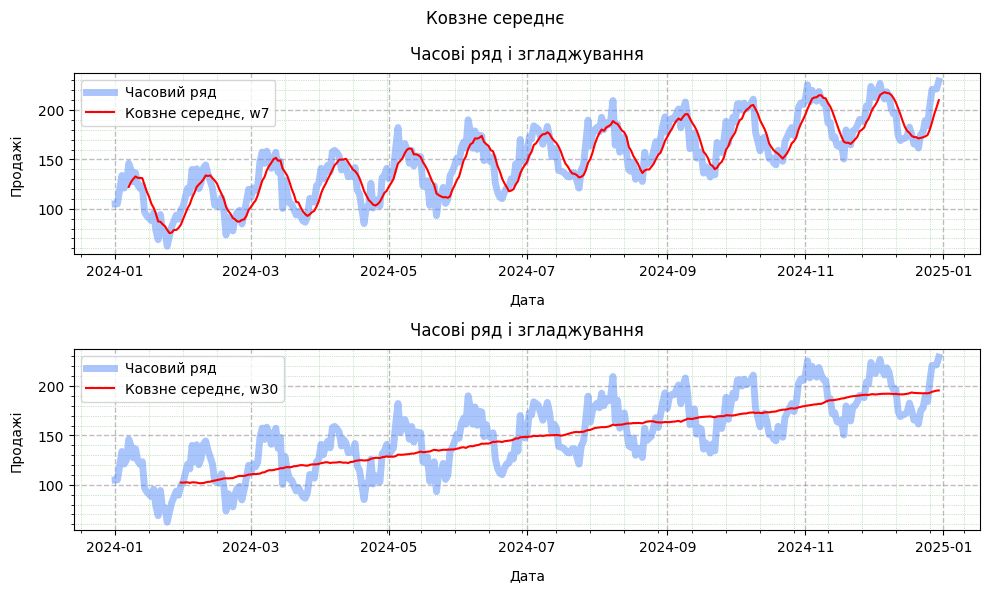

In [65]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, axes = plt.subplots(len(windows_sizes), 1, figsize=(10, 6))

for idx, item in enumerate(windows_sizes):
    ax = axes[idx]
    col_name = f"moving_avg_{item}"

    ax.plot(df["date"], df["sales_fixed"], linewidth=5.0, alpha=0.5, label="Часовий ряд")
    ax.plot(df["date"], df[col_name], linewidth=1.5, color="red", label=f"Ковзне середнє, w{item}")

    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title("Часові ряд і згладжування", pad=10, loc='center', color='black')
    ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Продажі", labelpad=10, loc='center', color='black')
    ax.legend()

plt.suptitle(f"Ковзне середнє")

plt.tight_layout()
plt.show()